In [3]:
import pandas as pd

df1 = pd.read_csv('vols_aplatis_BON.csv')
df2 = pd.read_csv('vols_aplatis_rate.csv')



df_merged = pd.concat([df1, df2], ignore_index=True)
df_merged['mission_id'] = df_merged['mission_id'].astype(int)

df_merged.to_csv('missions_fusionnees.csv', index=False)

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv('missions_fusionnees.csv')

In [5]:
df=df.drop(columns=['mission_id'],axis=1) 

Valeurs manquantes après imputation: 0

=== Performance du modèle ===
              precision    recall  f1-score   support

         0.0       0.85      0.62      0.72       186
         1.0       0.63      0.85      0.73       141

    accuracy                           0.72       327
   macro avg       0.74      0.74      0.72       327
weighted avg       0.75      0.72      0.72       327

Accuracy: 0.7217


c:\Users\Amatek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


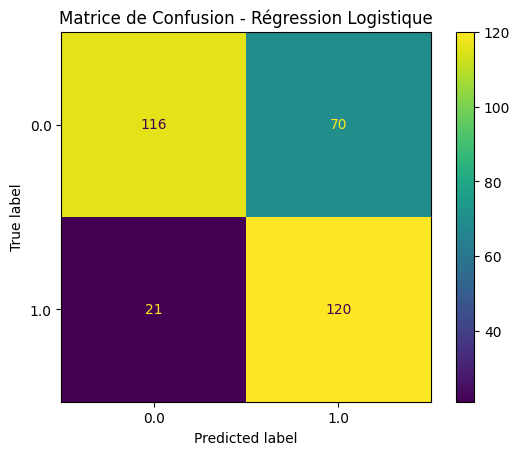

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv('missions_fusionnees.csv')



# 3. Sélection des features
time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack'] + time_cols, axis=1, errors='ignore')

# 4. Conversion en valeurs numériques et gestion des NaN
features = features.apply(pd.to_numeric, errors='coerce')

# 5. Imputation des valeurs manquantes
imputer = SimpleImputer(strategy='mean')  # Alternative: 'median' ou 'most_frequent'
features_imputed = imputer.fit_transform(features)

# 6. Vérification des NaN restants
print("Valeurs manquantes après imputation:", np.isnan(features_imputed).sum())

# 7. Split des données
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['is_attack']
)

# 8. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Modèle Logistic Regression avec gestion d'erreurs
try:
    lr = LogisticRegression(
        max_iter=1,
        random_state=42,
        class_weight='balanced'
    )
    lr.fit(X_train_scaled, y_train)
    
    # 10. Évaluation
    y_pred = lr.predict(X_test_scaled)
    
    print("\n=== Performance du modèle ===")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
    disp.plot()
    plt.title("Matrice de Confusion - Régression Logistique")
    plt.show()

except Exception as e:
    print(f"Erreur lors de l'entraînement: {str(e)}")
    print("\nVérifiez que:")
    print("1. Toutes les colonnes sont numériques")
    print("2. Il n'y a pas de valeurs NaN dans les données")
    print("3. La target ne contient que 0 et 1")

=== SVM ===
              precision    recall  f1-score   support

         0.0       0.83      0.82      0.83       124
         1.0       0.77      0.78      0.77        94

    accuracy                           0.80       218
   macro avg       0.80      0.80      0.80       218
weighted avg       0.80      0.80      0.80       218

Accuracy: 0.8027522935779816


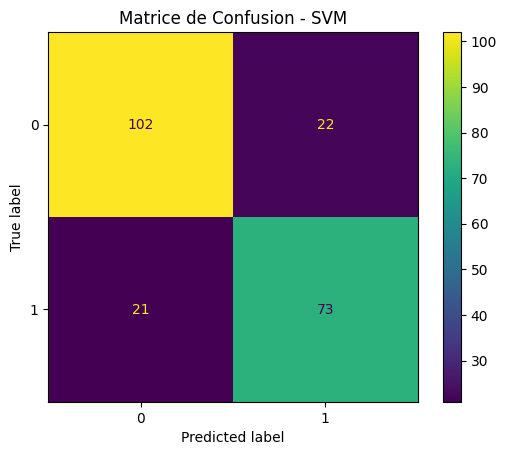

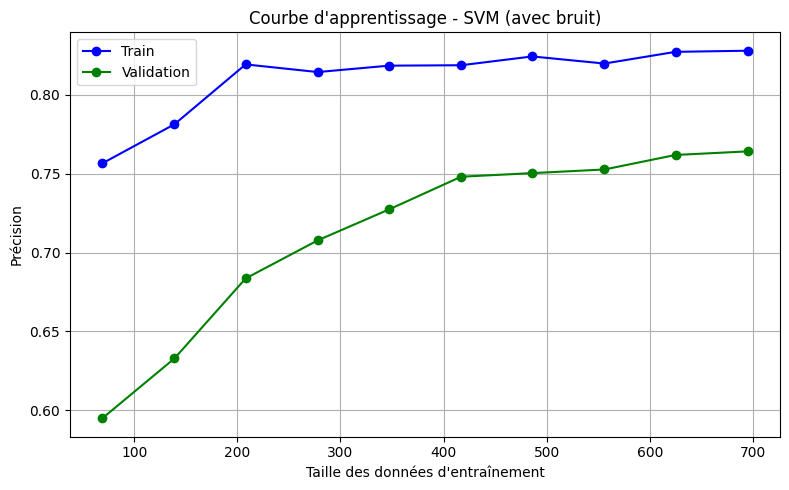

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("missions_fusionnees.csv")

X = df.drop(columns=["is_attack"])
y = df["is_attack"]

X = X.fillna(X.mean(numeric_only=True))

idx_shuffle = X.sample(frac=0.25, random_state=2).index
X.loc[idx_shuffle] = X.loc[idx_shuffle].sample(frac=1, random_state=2).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = StandardScaler().fit(X_train).transform(X_test) 

svm = SVC(kernel='rbf', C=0.6, gamma='scale')  
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

print("=== SVM ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de Confusion - SVM")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    svm, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Train", color='blue')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validation", color='green')
plt.title("Courbe d'apprentissage - SVM (avec bruit)")
plt.xlabel("Taille des données d'entraînement")
plt.ylabel("Précision")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



=== Performance du modèle KNN (sans optimisation) ===
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81       124
         1.0       0.71      0.94      0.81        94

    accuracy                           0.81       218
   macro avg       0.82      0.82      0.81       218
weighted avg       0.84      0.81      0.81       218

Accuracy: 0.8073


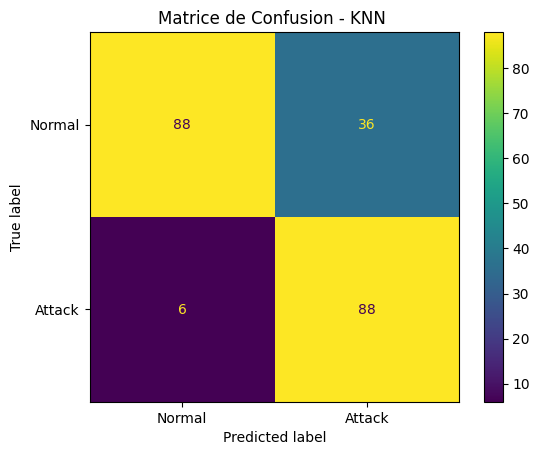

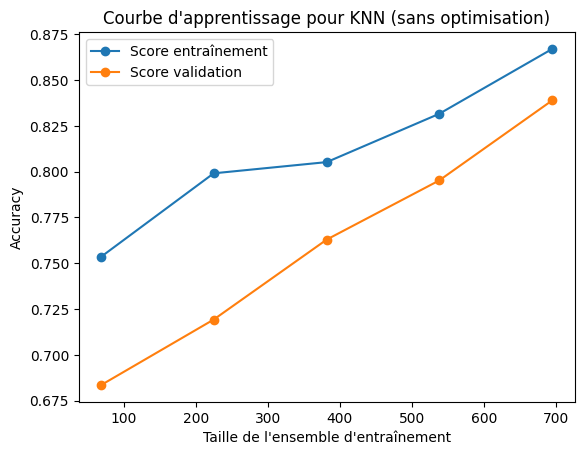

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack', 'erreur_m'] + time_cols, axis=1, errors='ignore')
features = features.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.2, 
    random_state=43,
    stratify=df['is_attack']
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(
    n_neighbors=12,      
    weights='uniform',   
    metric='euclidean'   
)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print("\n=== Performance du modèle KNN (sans optimisation) ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot()
plt.title("Matrice de Confusion - KNN ")
plt.show()

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    knn, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Score entraînement")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Score validation")
plt.title("Courbe d'apprentissage pour KNN (sans optimisation)")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Meilleur score (validation): 0.8769

=== Performance du modèle KNN ===
              precision    recall  f1-score   support

         0.0       0.96      0.79      0.87       124
         1.0       0.78      0.96      0.86        94

    accuracy                           0.86       218
   macro avg       0.87      0.87      0.86       218
weighted avg       0.88      0.86      0.86       218

Accuracy: 0.8624


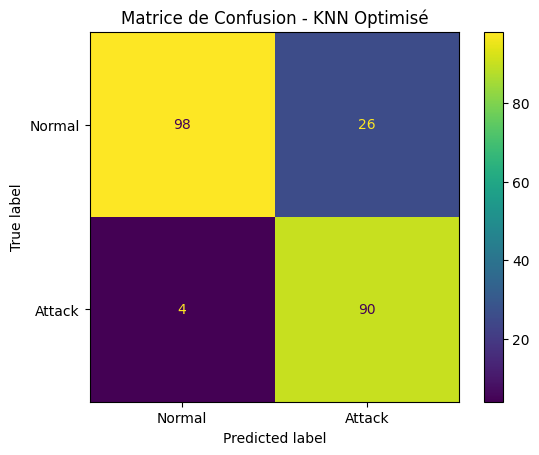

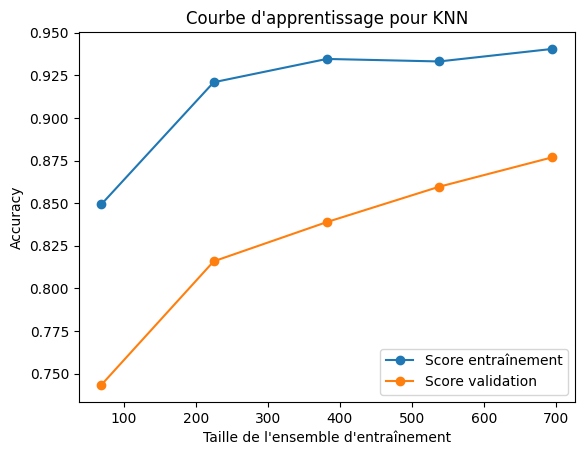

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier  # Import manquant ajouté ici
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt






time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack','erreur_m'] + time_cols, axis=1, errors='ignore')
features = features.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['is_attack']
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_knn = grid.best_estimator_
print(f"Meilleurs paramètres: {grid.best_params_}")
print(f"Meilleur score (validation): {grid.best_score_:.4f}")

y_pred = best_knn.predict(X_test_scaled)
print("\n=== Performance du modèle KNN ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot()
plt.title("Matrice de Confusion - KNN Optimisé")
plt.show()

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Score entraînement")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Score validation")
plt.title("Courbe d'apprentissage pour KNN")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.show()     